# Narrativa Convincente vs Verdade Analítica
## Proposta 08 — Empresas Listadas (CVM)

**Pergunta:** Qual empresa está mais saudável financeiramente?

**Hipótese inicial (narrativa ingênua):** A empresa com maior lucro líquido é a mais saudável financeiramente.

**Fonte:** [Portal de Dados Abertos CVM](https://dados.cvm.gov.br/) — Demonstrações Financeiras Padronizadas (DFP) de companhias abertas (2022–2024).

---

In [3]:
# baixar os dados financeiros da CVM para análise
import os
import urllib.request
import zipfile

# Download DFP (Demonstrações Financeiras Padronizadas) da CVM
# Fonte: https://dados.cvm.gov.br/dados/CIA_ABERTA/DOC/DFP/DADOS/

DATA_DIR = "./data"
BASE_URL = "https://dados.cvm.gov.br/dados/CIA_ABERTA/DOC/DFP/DADOS"

os.makedirs(DATA_DIR, exist_ok=True)

for year in [2022, 2023, 2024]:
    filename = f"dfp_cia_aberta_{year}.zip"
    filepath = os.path.join(DATA_DIR, filename)
    url = f"{BASE_URL}/{filename}"

    print(f"Baixando {filename}...")
    urllib.request.urlretrieve(url, filepath)

    print(f"Descompactando {filename}...")
    with zipfile.ZipFile(filepath, "r") as z:
        z.extractall(os.path.join(DATA_DIR, f"dfp_{year}"))

    print(f"OK: {filename}\n")

print(f"Download concluído. Arquivos em {DATA_DIR}/")

Baixando dfp_cia_aberta_2022.zip...
Descompactando dfp_cia_aberta_2022.zip...
OK: dfp_cia_aberta_2022.zip

Baixando dfp_cia_aberta_2023.zip...
Descompactando dfp_cia_aberta_2023.zip...
OK: dfp_cia_aberta_2023.zip

Baixando dfp_cia_aberta_2024.zip...
Descompactando dfp_cia_aberta_2024.zip...
OK: dfp_cia_aberta_2024.zip

Download concluído. Arquivos em ./data/


## 1. Problema e Hipótese Inicial

Investidores e analistas frequentemente recorrem ao **lucro líquido** como indicador principal de saúde financeira. A lógica parece simples: a empresa que mais lucra é a mais saudável.

Nesta primeira análise, vamos testar essa premissa usando os dados públicos das demonstrações financeiras (DFP) das companhias abertas registradas na CVM.

**Hipótese:** As empresas com maior lucro líquido absoluto são as mais saudáveis financeiramente.

## 2. Fonte e Descrição dos Dados

Os dados vêm do **Portal de Dados Abertos da CVM** ([dados.cvm.gov.br](https://dados.cvm.gov.br/dados/CIA_ABERTA/DOC/DFP/DADOS/)).

Utilizamos as **Demonstrações Financeiras Padronizadas (DFP)** consolidadas dos anos 2022, 2023 e 2024, que contêm:
- **DRE** (Demonstração de Resultado): receitas, custos e lucro líquido
- **BPA** (Balanço Patrimonial Ativo): ativo total e composição
- **BPP** (Balanço Patrimonial Passivo): passivo, endividamento e patrimônio líquido

Também utilizamos o **Cadastro de Companhias Abertas** para classificação setorial (`SETOR_ATIV`).

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# === Ingestão dos dados DRE consolidados (2022-2024) ===
anos = [2022, 2023, 2024]
dfs_dre = []

for ano in anos:
    path = f'./data/dfp_{ano}/dfp_cia_aberta_DRE_con_{ano}.csv'
    df = pd.read_csv(path, sep=';', encoding='latin1')
    df['ANO_DFP'] = ano
    dfs_dre.append(df)

dre_raw = pd.concat(dfs_dre, ignore_index=True)
print(f'DRE consolidado carregado: {dre_raw.shape[0]:,} linhas, {dre_raw.shape[1]} colunas')
print(f'Anos: {sorted(dre_raw["ANO_DFP"].unique())}')
print(f'Colunas: {dre_raw.columns.tolist()}')

DRE consolidado carregado: 100,530 linhas, 16 colunas
Anos: [np.int64(2022), np.int64(2023), np.int64(2024)]
Colunas: ['CNPJ_CIA', 'DT_REFER', 'VERSAO', 'DENOM_CIA', 'CD_CVM', 'GRUPO_DFP', 'MOEDA', 'ESCALA_MOEDA', 'ORDEM_EXERC', 'DT_INI_EXERC', 'DT_FIM_EXERC', 'CD_CONTA', 'DS_CONTA', 'VL_CONTA', 'ST_CONTA_FIXA', 'ANO_DFP']


In [5]:
# === Ingestão do Cadastro de Companhias (setor de atividade) ===
cad_url = 'https://dados.cvm.gov.br/dados/CIA_ABERTA/CAD/DADOS/cad_cia_aberta.csv'
cadastro = pd.read_csv(cad_url, sep=';', encoding='latin1')

# Manter apenas empresas ativas
cadastro_ativo = cadastro[cadastro['SIT'] == 'ATIVO'][['CNPJ_CIA', 'DENOM_SOCIAL', 'SETOR_ATIV']].copy()
cadastro_ativo = cadastro_ativo.drop_duplicates(subset='CNPJ_CIA')

print(f'Cadastro carregado: {len(cadastro_ativo)} empresas ativas')
print(f'Setores disponíveis: {cadastro_ativo["SETOR_ATIV"].nunique()}')

Cadastro carregado: 670 empresas ativas
Setores disponíveis: 53


## 3. Qualidade dos Dados (nulos, tipos, anomalias)

Antes de qualquer análise, verificamos a qualidade dos dados brutos:
- Presença de **valores nulos** por coluna
- **Tipos de dados** e consistência
- **Escala monetária** (algumas empresas reportam em MIL, outras em UNIDADE)
- **Exercícios fiscais** com diferentes meses de encerramento
- **Versões** múltiplas de entrega à CVM

In [6]:
# === Diagnóstico de qualidade ===
print('--- Nulos por coluna (DRE raw) ---')
print(dre_raw.isnull().sum()[dre_raw.isnull().sum() > 0])
print()

print('--- Tipos de dados ---')
print(dre_raw.dtypes)
print()

print(f'--- ESCALA_MOEDA (atenção: valores em escalas diferentes!) ---')
print(dre_raw['ESCALA_MOEDA'].value_counts())
print()

print(f'--- ORDEM_EXERC ---')
print(dre_raw['ORDEM_EXERC'].value_counts())
print()

# Verificar datas de encerramento
print(f'--- DT_FIM_EXERC (meses de encerramento) ---')
dre_raw['MES_FIM'] = pd.to_datetime(dre_raw['DT_FIM_EXERC']).dt.month
print(dre_raw.groupby('ANO_DFP')['MES_FIM'].value_counts().sort_index())

--- Nulos por coluna (DRE raw) ---
Series([], dtype: int64)

--- Tipos de dados ---
CNPJ_CIA             str
DT_REFER             str
VERSAO             int64
DENOM_CIA            str
CD_CVM             int64
GRUPO_DFP            str
MOEDA                str
ESCALA_MOEDA         str
ORDEM_EXERC          str
DT_INI_EXERC         str
DT_FIM_EXERC         str
CD_CONTA             str
DS_CONTA             str
VL_CONTA         float64
ST_CONTA_FIXA        str
ANO_DFP            int64
dtype: object

--- ESCALA_MOEDA (atenção: valores em escalas diferentes!) ---
ESCALA_MOEDA
MIL        98772
UNIDADE     1758
Name: count, dtype: int64

--- ORDEM_EXERC ---
ORDEM_EXERC
ÚLTIMO       50315
PENÚLTIMO    50215
Name: count, dtype: int64

--- DT_FIM_EXERC (meses de encerramento) ---
ANO_DFP  MES_FIM
2022     2             60
         3            523
         6            192
         9             30
         12         32979
2023     2             60
         3            504
         6            1

In [7]:
# === Tratamento: filtrar e extrair lucro líquido ===

# 1. Manter apenas exercício mais recente (ÚLTIMO)
dre = dre_raw[dre_raw['ORDEM_EXERC'] == 'ÚLTIMO'].copy()

# 2. Manter apenas exercícios com encerramento em dezembro (ano fiscal padrão)
dre['DT_FIM_EXERC'] = pd.to_datetime(dre['DT_FIM_EXERC'])
dre = dre[dre['DT_FIM_EXERC'].dt.month == 12]

# 3. Manter apenas a última versão entregue à CVM (maior VERSAO)
dre = dre.sort_values('VERSAO').groupby(['CNPJ_CIA', 'ANO_DFP', 'CD_CONTA']).tail(1)

# 4. Extrair conta de Lucro/Prejuízo Consolidado do Período
lucro_mask = dre['DS_CONTA'].str.contains(
    'Lucro.*Consolidado do Período|Prejuízo.*Líquido Consolidado do Período',
    na=False, case=False
)
lucro_df = dre[lucro_mask].copy()

# Pegar a conta de maior código por empresa/ano (resultado final do DRE)
lucro_df = lucro_df.sort_values('CD_CONTA').groupby(['CNPJ_CIA', 'ANO_DFP']).tail(1)

# 5. Normalizar escala monetária → tudo em REAIS
lucro_df['LUCRO_LIQUIDO'] = lucro_df.apply(
    lambda r: r['VL_CONTA'] * 1000 if r['ESCALA_MOEDA'] == 'MIL' else r['VL_CONTA'],
    axis=1
)

# 6. Remover nulos
antes = len(lucro_df)
lucro_df = lucro_df.dropna(subset=['LUCRO_LIQUIDO', 'DENOM_CIA'])
depois = len(lucro_df)

print(f'Registros após tratamento: {depois} (removidos {antes - depois} nulos)')
print(f'Empresas únicas: {lucro_df["DENOM_CIA"].nunique()}')
print(f'Anos: {sorted(lucro_df["ANO_DFP"].unique())}')
lucro_df[['DENOM_CIA', 'ANO_DFP', 'LUCRO_LIQUIDO', 'ESCALA_MOEDA']].head(10)

Registros após tratamento: 1385 (removidos 0 nulos)
Empresas únicas: 502
Anos: [np.int64(2022), np.int64(2023), np.int64(2024)]


,DENOM_CIA,ANO_DFP,LUCRO_LIQUIDO,ESCALA_MOEDA
26141,BCO PAN S.A.,2022,6.682830e+08,MIL
19903,BANCO MODAL S.A.,2022,4.890200e+07,MIL
94127,ITAU UNIBANCO HOLDING S.A.,2024,4.212800e+10,MIL
95007,BANCO BMG S/A,2024,2.793490e+08,MIL
95669,BCO PINE S.A,2024,1.017340e+08,MIL
82931,BANCO NACIONAL S.A.,2024,3.981060e+08,MIL
93159,BCO PAN S.A.,2024,5.282290e+08,MIL
60119,BCO PAN S.A.,2023,5.916760e+08,MIL
53227,BCO BTG PACTUAL S.A.,2023,1.025476e+10,MIL
86671,BCO BTG PACTUAL S.A.,2024,1.108044e+10,MIL


## 4. Narrativa Inicial — "Quem lucra mais é mais saudável"

Vamos adotar a visão mais simples e direta: **ranquear as empresas pelo lucro líquido absoluto** e concluir que as que mais lucram são as mais saudáveis financeiramente.

Além do volume de lucro, vamos observar a **variação do lucro entre os anos** (2022–2024) — sob esta lógica ingênua, uma empresa que lucra muito e mantém seu lucro crescente ou estável seria a mais saudável de todas.

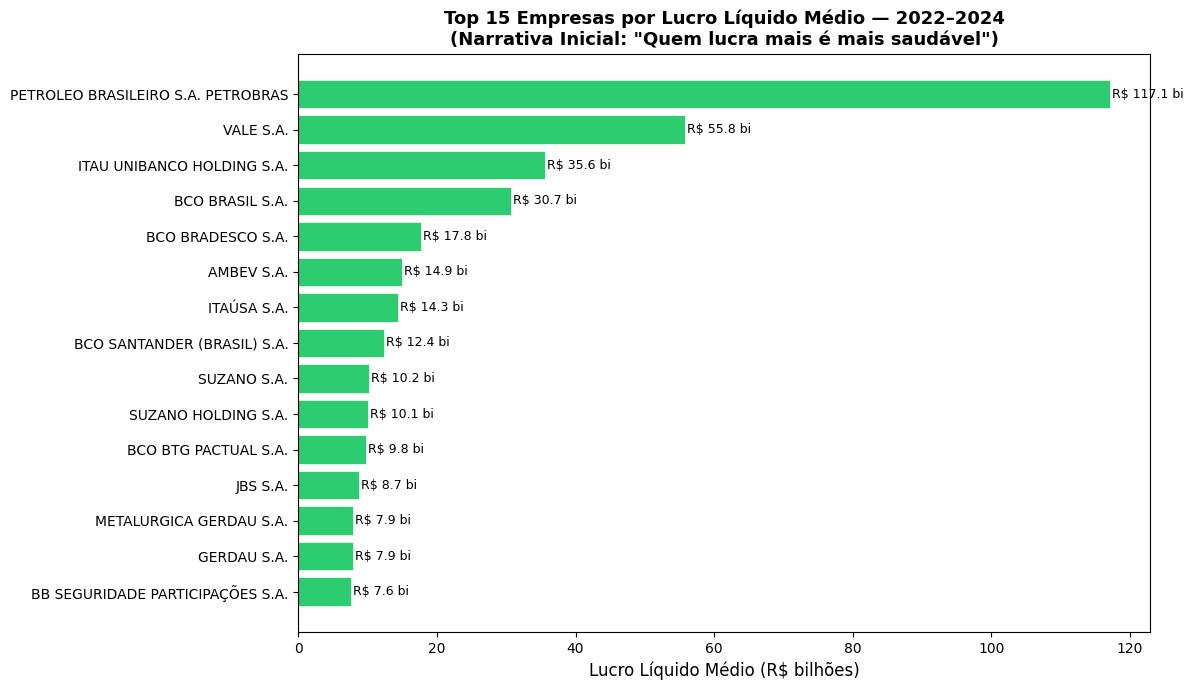

In [8]:
# === Ranking e gráfico: Top 15 empresas por Lucro Líquido Médio (2022-2024) ===
lucro_medio = (
    lucro_df.groupby(['CNPJ_CIA', 'DENOM_CIA'])['LUCRO_LIQUIDO']
    .mean()
    .reset_index()
    .rename(columns={'LUCRO_LIQUIDO': 'LUCRO_MEDIO'})
)
lucro_medio['LUCRO_MEDIO_BI'] = lucro_medio['LUCRO_MEDIO'] / 1e9

top15 = lucro_medio.nlargest(15, 'LUCRO_MEDIO')[['DENOM_CIA', 'LUCRO_MEDIO_BI']].reset_index(drop=True)
top15.index += 1
top15.columns = ['Empresa', 'Lucro Líquido Médio (R$ bi)']

fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in top15['Lucro Líquido Médio (R$ bi)']]
bars = ax.barh(
    top15['Empresa'][::-1],
    top15['Lucro Líquido Médio (R$ bi)'][::-1],
    color=colors[::-1],
    edgecolor='white',
    linewidth=0.5
)

ax.set_xlabel('Lucro Líquido Médio (R$ bilhões)', fontsize=12)
ax.set_title('Top 15 Empresas por Lucro Líquido Médio — 2022–2024\n(Narrativa Inicial: "Quem lucra mais é mais saudável")',
             fontsize=13, fontweight='bold')
ax.axvline(x=0, color='gray', linewidth=0.8)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.3, bar.get_y() + bar.get_height()/2,
            f'R$ {width:.1f} bi', va='center', fontsize=9)

plt.tight_layout()
plt.show()

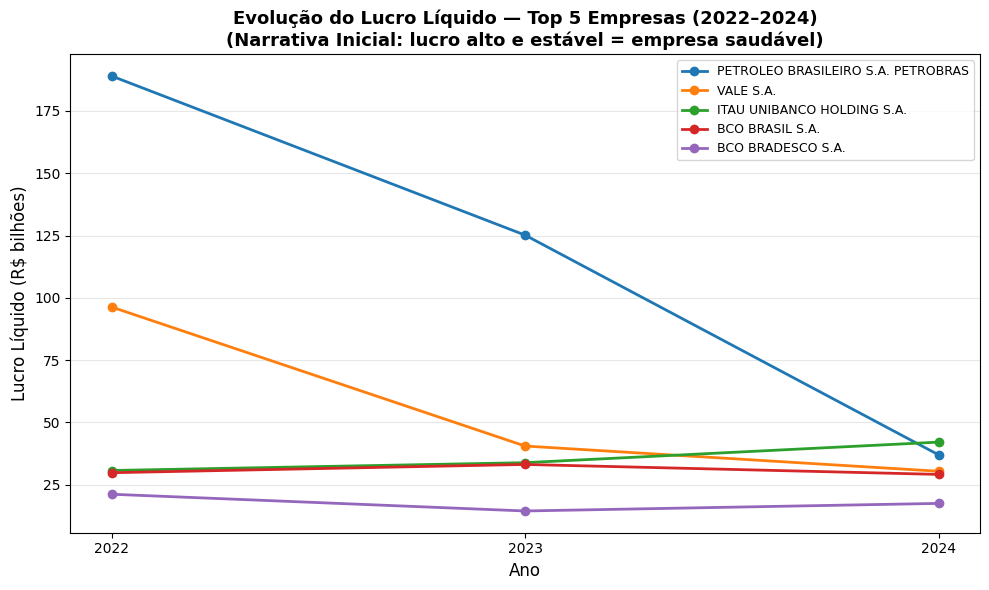

In [9]:
# === Gráfico temporal: evolução do lucro das Top 5 (2022-2024) ===
top5_nomes = lucro_medio.nlargest(5, 'LUCRO_MEDIO')['DENOM_CIA'].tolist()
top5_hist = lucro_df[lucro_df['DENOM_CIA'].isin(top5_nomes)].copy()
top5_hist['LUCRO_BI'] = top5_hist['LUCRO_LIQUIDO'] / 1e9

fig, ax = plt.subplots(figsize=(10, 6))
for nome in top5_nomes:
    dados = top5_hist[top5_hist['DENOM_CIA'] == nome].sort_values('ANO_DFP')
    ax.plot(dados['ANO_DFP'], dados['LUCRO_BI'], marker='o', linewidth=2, label=nome)

ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Lucro Líquido (R$ bilhões)', fontsize=12)
ax.set_title('Evolução do Lucro Líquido — Top 5 Empresas (2022–2024)\n(Narrativa Inicial: lucro alto e estável = empresa saudável)',
             fontsize=13, fontweight='bold')
ax.set_xticks(anos)
ax.legend(fontsize=9, loc='best')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

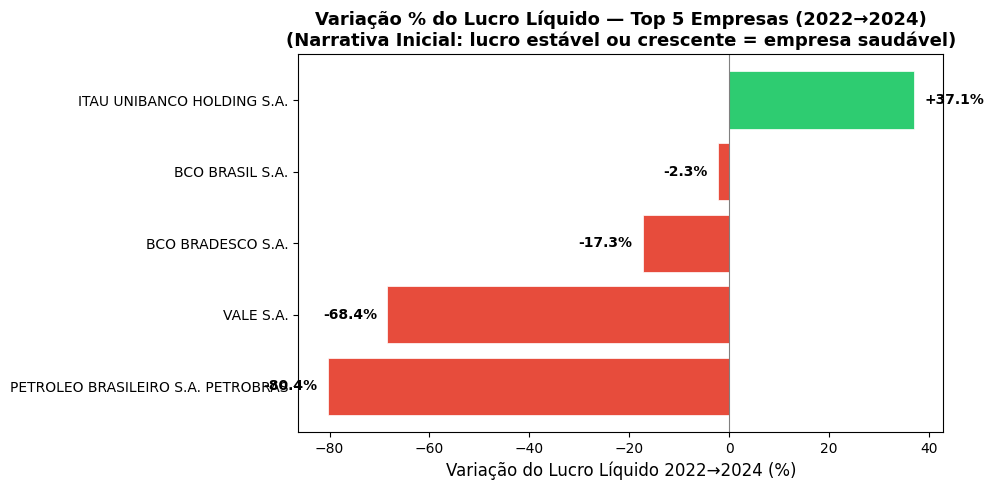

In [10]:
# === Gráfico: Variação % do lucro 2022→2024 das Top 5 ===
top5_var = top5_hist.pivot_table(index='DENOM_CIA', columns='ANO_DFP', values='LUCRO_BI')
top5_var['Variação (%)'] = ((top5_var[2024] - top5_var[2022]) / top5_var[2022].abs()) * 100
top5_var = top5_var.sort_values('Variação (%)', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in top5_var['Variação (%)']]
bars = ax.barh(top5_var.index, top5_var['Variação (%)'], color=colors, edgecolor='white', linewidth=0.5)

ax.set_xlabel('Variação do Lucro Líquido 2022→2024 (%)', fontsize=12)
ax.set_title('Variação % do Lucro Líquido — Top 5 Empresas (2022→2024)\n(Narrativa Inicial: lucro estável ou crescente = empresa saudável)',
             fontsize=13, fontweight='bold')
ax.axvline(x=0, color='gray', linewidth=0.8)

for bar in bars:
    width = bar.get_width()
    offset = 2 if width >= 0 else -2
    ha = 'left' if width >= 0 else 'right'
    ax.text(width + offset, bar.get_y() + bar.get_height()/2,
            f'{width:+.1f}%', va='center', ha=ha, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Conclusão da Narrativa Inicial

Com base no **lucro líquido absoluto** e na sua **estabilidade**, as empresas mais "saudáveis" do Brasil seriam os grandes bancos (Itaú, Banco do Brasil e Bradesco) — que além de lucrar dezenas de bilhões, mantêm seus resultados relativamente estáveis entre 2022 e 2024. Já a Petrobras, apesar do lucro expressivo, apresenta uma queda acentuada no período.

## 5. Correções e Testes de Robustez

A narrativa inicial avaliou saúde financeira apenas pelo **lucro líquido absoluto**. O problema é que lucro isolado não representa saúde financeira completa.

### Correções metodológicas aplicadas:
1. **Incorporar múltiplos indicadores**: Margem Líquida, ROA e Endividamento
2. **Comparação setorial**: usar o cadastro CVM para agrupar empresas do mesmo setor — evitando comparações injustas (ex: banco vs indústria têxtil)
3. **Teste de robustez**: usar mediana em vez de média para reduzir influência de outliers

### Indicadores calculados:
- **Margem Líquida** = Lucro Líquido / Receita Líquida
- **ROA** (Return on Assets) = Lucro Líquido / Ativo Total 
- **Endividamento** = (Passivo Total − PL) / Patrimônio Líquido

In [11]:
# === Ingestão dos dados BPA e BPP consolidados (2022-2024) ===
dfs_bpa = []
dfs_bpp = []

for ano in anos:
    bpa = pd.read_csv(f'./data/dfp_{ano}/dfp_cia_aberta_BPA_con_{ano}.csv', sep=';', encoding='latin1')
    bpp = pd.read_csv(f'./data/dfp_{ano}/dfp_cia_aberta_BPP_con_{ano}.csv', sep=';', encoding='latin1')
    bpa['ANO_DFP'] = ano
    bpp['ANO_DFP'] = ano
    dfs_bpa.append(bpa)
    dfs_bpp.append(bpp)

bpa_raw = pd.concat(dfs_bpa, ignore_index=True)
bpp_raw = pd.concat(dfs_bpp, ignore_index=True)

print(f'BPA carregado: {bpa_raw.shape[0]:,} linhas')
print(f'BPP carregado: {bpp_raw.shape[0]:,} linhas')

BPA carregado: 191,120 linhas
BPP carregado: 326,740 linhas


In [12]:
# === Extração das contas-chave: Receita, Ativo Total, Passivo Total, PL ===
def extrair_conta(df_raw, cd_conta=None, ds_conta_regex=None, nome_coluna='VALOR'):
    """Extrai uma conta específica dos dados brutos, normaliza escala e retorna por empresa/ano."""
    df = df_raw[df_raw['ORDEM_EXERC'] == 'ÚLTIMO'].copy()
    df['DT_FIM_EXERC'] = pd.to_datetime(df['DT_FIM_EXERC'])
    df = df[df['DT_FIM_EXERC'].dt.month == 12]
    df = df.sort_values('VERSAO').groupby(['CNPJ_CIA', 'ANO_DFP', 'CD_CONTA']).tail(1)
    
    if cd_conta:
        df = df[df['CD_CONTA'] == cd_conta]
    elif ds_conta_regex:
        df = df[df['DS_CONTA'].str.contains(ds_conta_regex, na=False, case=False)]
        df = df.sort_values('CD_CONTA').groupby(['CNPJ_CIA', 'ANO_DFP']).tail(1)
    
    df[nome_coluna] = df.apply(
        lambda r: r['VL_CONTA'] * 1000 if r['ESCALA_MOEDA'] == 'MIL' else r['VL_CONTA'],
        axis=1
    )
    return df[['CNPJ_CIA', 'DENOM_CIA', 'ANO_DFP', nome_coluna]].copy()

# Receita Líquida (DRE 3.01)
receita_df = extrair_conta(dre_raw, cd_conta='3.01', nome_coluna='RECEITA')

# Ativo Total (BPA conta 1)
ativo_df = extrair_conta(bpa_raw, cd_conta='1', nome_coluna='ATIVO_TOTAL')

# Passivo Total (BPP conta 2)
passivo_df = extrair_conta(bpp_raw, cd_conta='2', nome_coluna='PASSIVO_TOTAL')

# Patrimônio Líquido Consolidado (BPP - última conta com esse nome)
pl_df = extrair_conta(bpp_raw, ds_conta_regex='Patrimônio Líquido Consolidado', nome_coluna='PL')

print(f'Receita: {receita_df["CNPJ_CIA"].nunique()} empresas')
print(f'Ativo Total: {ativo_df["CNPJ_CIA"].nunique()} empresas')
print(f'Passivo Total: {passivo_df["CNPJ_CIA"].nunique()} empresas')
print(f'PL: {pl_df["CNPJ_CIA"].nunique()} empresas')

Receita: 502 empresas
Ativo Total: 502 empresas
Passivo Total: 502 empresas
PL: 502 empresas


In [13]:
# === Merge: unificar todos os indicadores em um único DataFrame ===
base = lucro_df[['CNPJ_CIA', 'DENOM_CIA', 'ANO_DFP', 'LUCRO_LIQUIDO']].copy()

# Juntar receita, ativo, passivo e PL
for df_aux, col in [(receita_df, 'RECEITA'), (ativo_df, 'ATIVO_TOTAL'), 
                     (passivo_df, 'PASSIVO_TOTAL'), (pl_df, 'PL')]:
    base = base.merge(
        df_aux[['CNPJ_CIA', 'ANO_DFP', col]],
        on=['CNPJ_CIA', 'ANO_DFP'],
        how='left'
    )

# Juntar setor de atividade do cadastro CVM
base = base.merge(
    cadastro_ativo[['CNPJ_CIA', 'SETOR_ATIV']],
    on='CNPJ_CIA',
    how='left'
)

# Remover empresas sem dados completos
antes = len(base)
base = base.dropna(subset=['RECEITA', 'ATIVO_TOTAL', 'PASSIVO_TOTAL', 'PL'])
depois = len(base)

print(f'Base unificada: {depois} registros ({antes - depois} removidos por dados incompletos)')
print(f'Empresas: {base["DENOM_CIA"].nunique()} | Setores: {base["SETOR_ATIV"].nunique()}')
print(f'Anos: {sorted(base["ANO_DFP"].unique())}')

Base unificada: 1385 registros (0 removidos por dados incompletos)
Empresas: 502 | Setores: 48
Anos: [np.int64(2022), np.int64(2023), np.int64(2024)]


In [14]:
# === Cálculo dos indicadores de saúde financeira ===
# Margem Líquida (%) = Lucro / Receita
base['MARGEM_LIQUIDA'] = (base['LUCRO_LIQUIDO'] / base['RECEITA'].abs()) * 100

# ROA (%) = Lucro / Ativo Total
base['ROA'] = (base['LUCRO_LIQUIDO'] / base['ATIVO_TOTAL'].abs()) * 100

# Endividamento = (Passivo Total - PL) / PL
# Dívida = Passivo Total - PL (obrigações com terceiros)
base['DIVIDA'] = base['PASSIVO_TOTAL'] - base['PL']
base['ENDIVIDAMENTO'] = base['DIVIDA'] / base['PL'].abs()

# Remover infinitos (empresas com PL zero ou receita zero)
import numpy as np
base = base.replace([np.inf, -np.inf], np.nan)
base = base.dropna(subset=['MARGEM_LIQUIDA', 'ROA', 'ENDIVIDAMENTO'])

# Média dos indicadores por empresa (2022-2024)
indicadores = base.groupby(['CNPJ_CIA', 'DENOM_CIA', 'SETOR_ATIV']).agg(
    LUCRO_MEDIO=('LUCRO_LIQUIDO', 'mean'),
    MARGEM_LIQUIDA=('MARGEM_LIQUIDA', 'mean'),
    ROA=('ROA', 'mean'),
    ENDIVIDAMENTO=('ENDIVIDAMENTO', 'mean'),
).reset_index().round(2)

print(f'Indicadores calculados para {len(indicadores)} empresas')
print()
print('=== Estatísticas descritivas ===')
indicadores[['MARGEM_LIQUIDA', 'ROA', 'ENDIVIDAMENTO']].describe().round(2)

Indicadores calculados para 427 empresas

=== Estatísticas descritivas ===


,MARGEM_LIQUIDA,ROA,ENDIVIDAMENTO
count,427.00,427.00,427.00
mean,-1860.42,-3.78,9.41
std,38440.56,111.81,88.53
min,-794324.16,-2278.82,0.01
25%,-0.36,-0.06,1.00
50%,6.55,3.01,1.94
75%,14.79,7.20,3.58
max,2850.78,107.59,1754.76


In [15]:
# === Teste de robustez: mediana vs média por setor ===
# A média é sensível a outliers; a mediana é mais robusta
robustez = base.groupby('SETOR_ATIV').agg(
    MARGEM_MEDIA=('MARGEM_LIQUIDA', 'mean'),
    MARGEM_MEDIANA=('MARGEM_LIQUIDA', 'median'),
    ROA_MEDIO=('ROA', 'mean'),
    ROA_MEDIANA=('ROA', 'median'),
    ENDIV_MEDIO=('ENDIVIDAMENTO', 'mean'),
    ENDIV_MEDIANA=('ENDIVIDAMENTO', 'median'),
    N_EMPRESAS=('CNPJ_CIA', 'nunique'),
).round(2)

# Filtrar setores com pelo menos 5 empresas para comparação significativa
robustez = robustez[robustez['N_EMPRESAS'] >= 5].sort_values('N_EMPRESAS', ascending=False)

print(f'Setores com >= 5 empresas: {len(robustez)}')
print()
print('=== Média vs Mediana por setor (Top 10 setores por nº de empresas) ===')
robustez.head(10)

Setores com >= 5 empresas: 24

=== Média vs Mediana por setor (Top 10 setores por nº de empresas) ===


,MARGEM_MEDIA,MARGEM_MEDIANA,ROA_MEDIO,ROA_MEDIANA,ENDIV_MEDIO,ENDIV_MEDIANA,N_EMPRESAS
SETOR_ATIV,,,,,,,
"Construção Civil, Mat. Constr. e Decoração",-3.92,7.29,2.27,3.26,3.15,1.70,43
Comércio (Atacado e Varejo),-4.03,1.38,0.02,1.95,49.44,1.94,40
Energia Elétrica,15.66,12.36,4.15,4.09,5.05,2.10,33
Serviços Transporte e Logística,-1.20,3.22,-0.83,1.53,5.54,3.78,27
"Máquinas, Equipamentos, Veículos e Peças",-38321.01,5.00,-107.60,3.70,4.61,2.11,21
Emp. Adm. Part. - Energia Elétrica,9.22,11.51,3.07,4.06,7.34,2.15,20
Têxtil e Vestuário,-44.02,4.04,-9.79,2.22,4.56,1.50,17
Serviços Médicos,-1.09,-2.25,0.44,-1.03,2.46,1.95,15
Metalurgia e Siderurgia,-10.26,6.23,-1.98,5.23,3.93,1.19,14


In [16]:
# === Comparação: Top 15 pelo lucro vs Top 15 pelo indicador composto ===
# Criar score composto normalizado (quanto maior margem e ROA = melhor, quanto menor endividamento = melhor)
from scipy.stats import percentileofscore

def percentil_rank(series):
    """Converte valores em percentis (0-100)."""
    return series.apply(lambda x: percentileofscore(series.dropna(), x, kind='mean'))

indicadores['RANK_MARGEM'] = percentil_rank(indicadores['MARGEM_LIQUIDA'])
indicadores['RANK_ROA'] = percentil_rank(indicadores['ROA'])
indicadores['RANK_ENDIV'] = 100 - percentil_rank(indicadores['ENDIVIDAMENTO'])  # invertido: menor = melhor

# Score composto: média dos 3 rankings (peso igual)
indicadores['SCORE_SAUDE'] = (
    (indicadores['RANK_MARGEM'] + indicadores['RANK_ROA'] + indicadores['RANK_ENDIV']) / 3
).round(1)

# Comparar Top 15 lucro vs Top 15 score
top15_lucro = set(indicadores.nlargest(15, 'LUCRO_MEDIO')['DENOM_CIA'])
top15_score = set(indicadores.nlargest(15, 'SCORE_SAUDE')['DENOM_CIA'])

print('=== Top 15 por Lucro Médio ===')
for i, row in indicadores.nlargest(15, 'LUCRO_MEDIO')[['DENOM_CIA', 'LUCRO_MEDIO', 'SCORE_SAUDE']].reset_index(drop=True).iterrows():
    flag = '✓' if row['DENOM_CIA'] in top15_score else '✗'
    print(f"  {i+1:2d}. {flag} {row['DENOM_CIA']:<45s} Lucro: R$ {row['LUCRO_MEDIO']/1e9:.1f} bi | Score: {row['SCORE_SAUDE']}")

print()
print('=== Top 15 por Score de Saúde Financeira ===')
for i, row in indicadores.nlargest(15, 'SCORE_SAUDE')[['DENOM_CIA', 'LUCRO_MEDIO', 'SCORE_SAUDE']].reset_index(drop=True).iterrows():
    flag = '✓' if row['DENOM_CIA'] in top15_lucro else '✗'
    print(f"  {i+1:2d}. {flag} {row['DENOM_CIA']:<45s} Score: {row['SCORE_SAUDE']} | Lucro: R$ {row['LUCRO_MEDIO']/1e9:.1f} bi")

coincidencia = len(top15_lucro & top15_score)
print(f'\nEmpresas em comum nos dois rankings: {coincidencia}/15')

=== Top 15 por Lucro Médio ===
   1. ✗ PETROLEO BRASILEIRO S.A. PETROBRAS            Lucro: R$ 117.1 bi | Score: 75.2
   2. ✗ VALE S.A.                                     Lucro: R$ 55.8 bi | Score: 80.7
   3. ✗ ITAU UNIBANCO HOLDING S.A.                    Lucro: R$ 35.6 bi | Score: 37.2
   4. ✗ BCO BRASIL S.A.                               Lucro: R$ 30.7 bi | Score: 38.0
   5. ✗ BCO BRADESCO S.A.                             Lucro: R$ 17.8 bi | Score: 33.5
   6. ✗ AMBEV S.A.                                    Lucro: R$ 14.9 bi | Score: 84.9
   7. ✓ ITAÚSA S.A.                                   Lucro: R$ 14.3 bi | Score: 96.5
   8. ✗ BCO SANTANDER (BRASIL) S.A.                   Lucro: R$ 12.4 bi | Score: 36.6
   9. ✗ SUZANO S.A.                                   Lucro: R$ 10.2 bi | Score: 64.3
  10. ✗ SUZANO HOLDING S.A.                           Lucro: R$ 10.1 bi | Score: 64.1
  11. ✗ BCO BTG PACTUAL S.A.                          Lucro: R$ 9.8 bi | Score: 47.9
  12. ✗ JBS S.A.       

## 6. Narrativa Corrigida — "Saúde financeira vai além do lucro"

Agora que dispomos de um **score composto** baseado em Margem Líquida, ROA e Endividamento, podemos refazer o ranking e confrontar diretamente com a narrativa inicial.

Seguimos a mesma estrutura da seção anterior:

1. **Ranking comparativo** — Top 15 empresas pelo Score de Saúde Financeira3. **Antes vs Depois** — comparação visual entre os dois rankings
2. **Distribuição dos indicadores** — boxplot mostrando a dispersão real dos dados

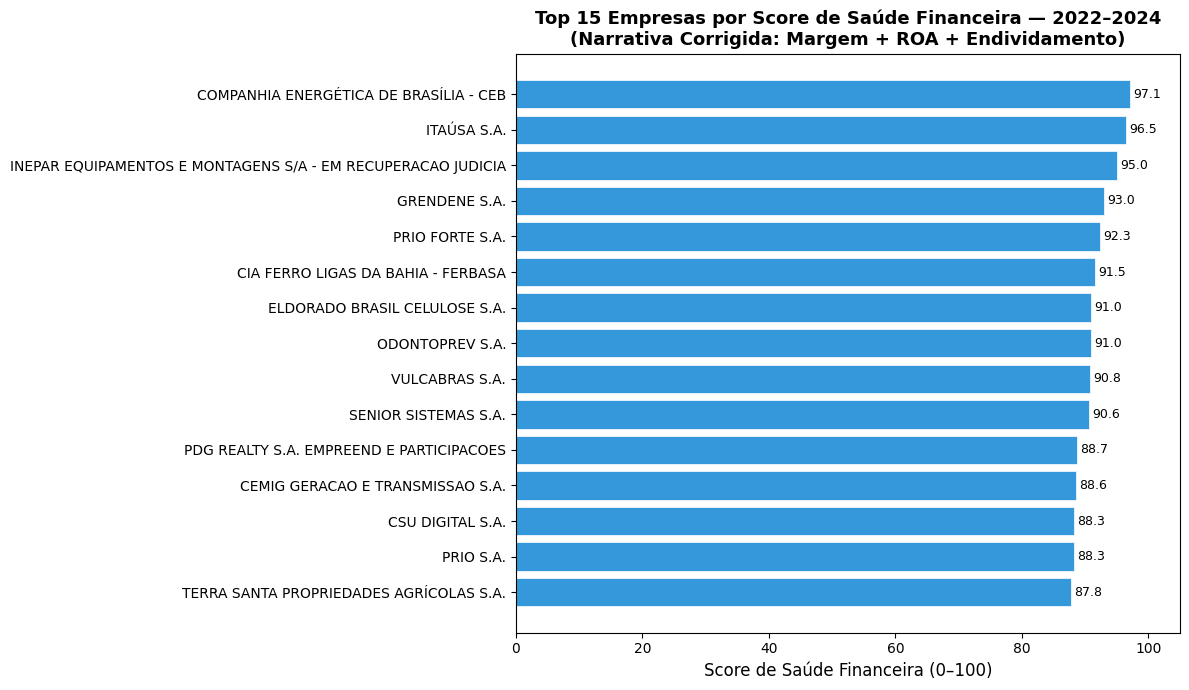

In [17]:
# === Ranking: Top 15 empresas por Score de Saúde Financeira ===
top15_score_df = indicadores.nlargest(15, 'SCORE_SAUDE')[['DENOM_CIA', 'SCORE_SAUDE', 'MARGEM_LIQUIDA', 'ROA', 'ENDIVIDAMENTO']].reset_index(drop=True)
top15_score_df.index += 1

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    top15_score_df['DENOM_CIA'][::-1],
    top15_score_df['SCORE_SAUDE'][::-1],
    color='#3498db',
    edgecolor='white',
    linewidth=0.5
)

ax.set_xlabel('Score de Saúde Financeira (0–100)', fontsize=12)
ax.set_title('Top 15 Empresas por Score de Saúde Financeira — 2022–2024\n(Narrativa Corrigida: Margem + ROA + Endividamento)',
             fontsize=13, fontweight='bold')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}', va='center', fontsize=9)

ax.set_xlim(0, 105)
plt.tight_layout()
plt.show()

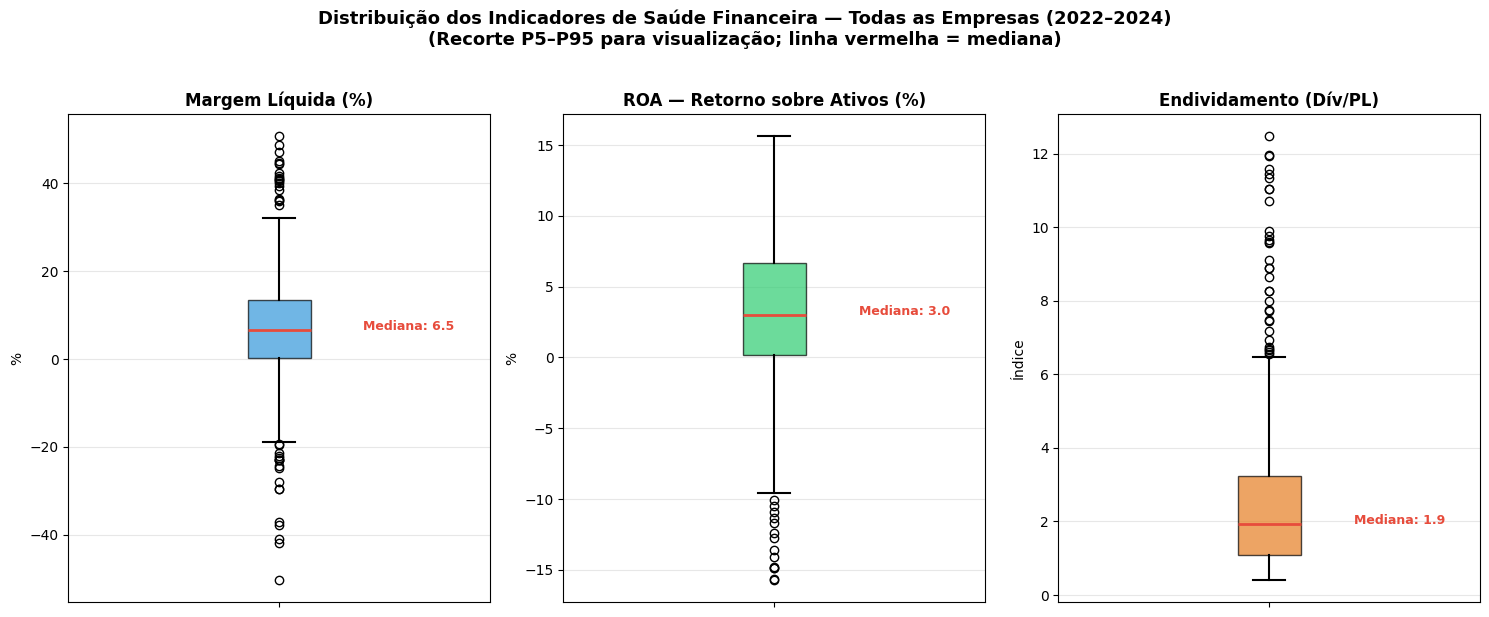


Total de empresas analisadas: 427


In [18]:
# === Gráfico de distribuição: boxplot dos 3 indicadores (todas as empresas) ===
# Recorte no percentil 5–95 para visualização legível (outliers extremos distorcem a escala)
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

indicadores_plot = indicadores[['MARGEM_LIQUIDA', 'ROA', 'ENDIVIDAMENTO']].copy()

configs = [
    ('MARGEM_LIQUIDA', 'Margem Líquida (%)', '%', '#3498db'),
    ('ROA', 'ROA — Retorno sobre Ativos (%)', '%', '#2ecc71'),
    ('ENDIVIDAMENTO', 'Endividamento (Dív/PL)', 'Índice', '#e67e22'),
]

for ax, (col, titulo, ylabel, cor) in zip(axes, configs):
    dados = indicadores_plot[col].dropna()
    q05, q95 = dados.quantile(0.05), dados.quantile(0.95)
    dados_clip = dados[(dados >= q05) & (dados <= q95)]
    
    ax.boxplot(dados_clip, vert=True, patch_artist=True,
               boxprops=dict(facecolor=cor, alpha=0.7),
               medianprops=dict(color='#e74c3c', linewidth=2),
               whiskerprops=dict(linewidth=1.5),
               capprops=dict(linewidth=1.5))
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels([''])
    
    # Anotar mediana
    med = dados_clip.median()
    ax.annotate(f'Mediana: {med:.1f}', xy=(1, med), xytext=(1.2, med),
                fontsize=9, color='#e74c3c', fontweight='bold')

fig.suptitle('Distribuição dos Indicadores de Saúde Financeira — Todas as Empresas (2022–2024)\n'
             '(Recorte P5–P95 para visualização; linha vermelha = mediana)',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

print(f'\nTotal de empresas analisadas: {len(indicadores)}')

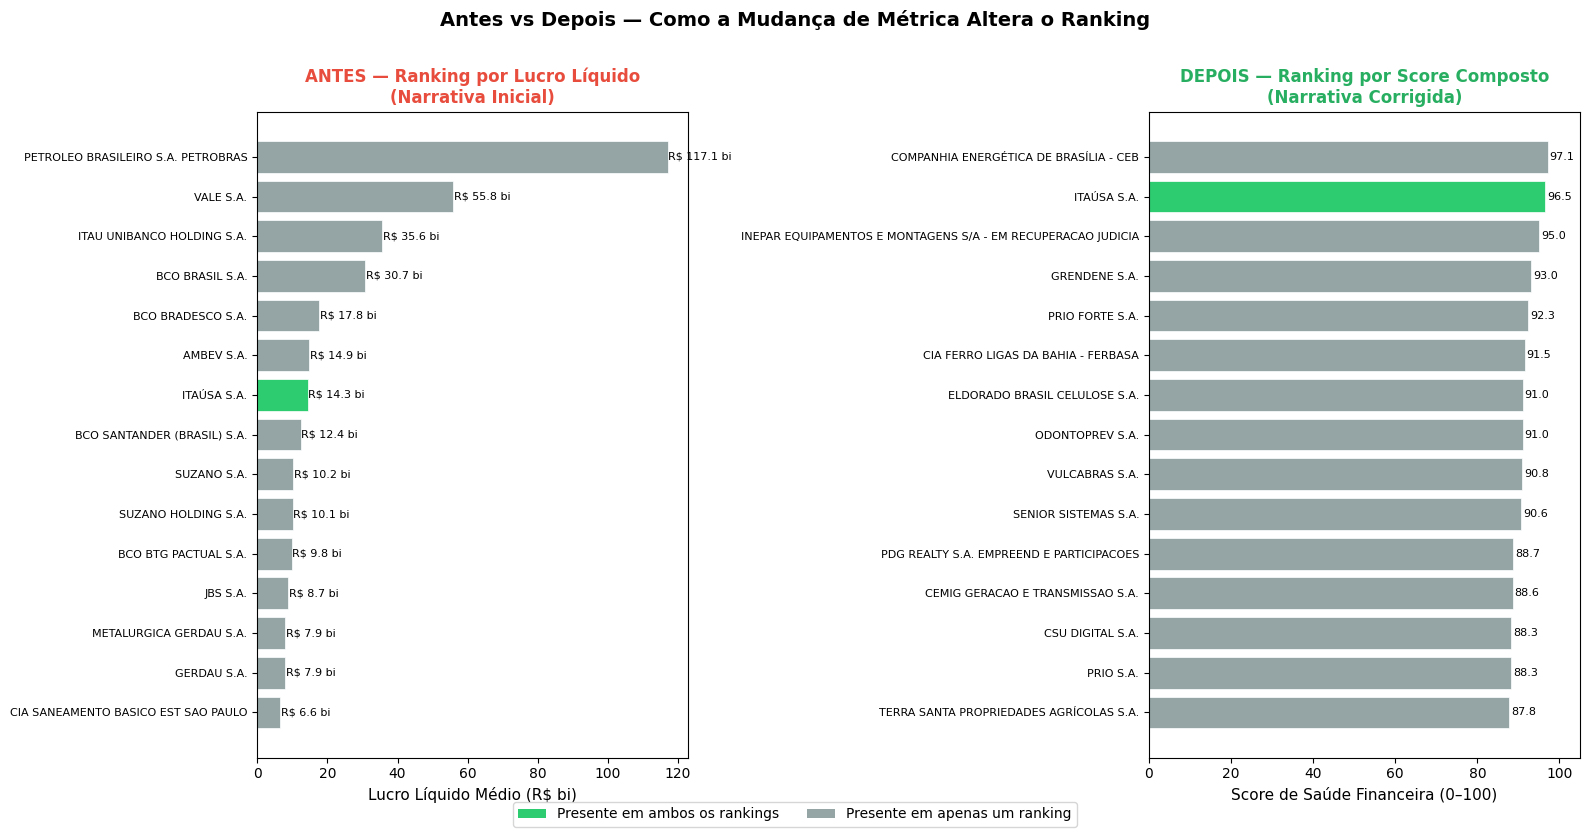

In [19]:
# === Antes vs Depois: comparação visual lado a lado dos dois rankings ===
top15_lucro_df = indicadores.nlargest(15, 'LUCRO_MEDIO')[['DENOM_CIA', 'LUCRO_MEDIO', 'SCORE_SAUDE']].reset_index(drop=True)
top15_saude_df = indicadores.nlargest(15, 'SCORE_SAUDE')[['DENOM_CIA', 'LUCRO_MEDIO', 'SCORE_SAUDE']].reset_index(drop=True)
top15_lucro_df.index += 1
top15_saude_df.index += 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# --- ANTES: Top 15 por Lucro ---
nomes_lucro = top15_lucro_df['DENOM_CIA'][::-1]
valores_lucro = (top15_lucro_df['LUCRO_MEDIO'] / 1e9)[::-1]

# Marcar em destaque quem NÃO aparece no ranking corrigido
cores_antes = ['#95a5a6' if n not in top15_score else '#2ecc71' for n in nomes_lucro]

ax1.barh(range(15), valores_lucro, color=cores_antes, edgecolor='white', linewidth=0.5)
ax1.set_yticks(range(15))
ax1.set_yticklabels(nomes_lucro, fontsize=8)
ax1.set_xlabel('Lucro Líquido Médio (R$ bi)', fontsize=11)
ax1.set_title('ANTES — Ranking por Lucro Líquido\n(Narrativa Inicial)', fontsize=12, fontweight='bold', color='#e74c3c')

for i, v in enumerate(valores_lucro):
    ax1.text(v + 0.2, i, f'R$ {v:.1f} bi', va='center', fontsize=8)

# --- DEPOIS: Top 15 por Score ---
nomes_score = top15_saude_df['DENOM_CIA'][::-1]
valores_score = top15_saude_df['SCORE_SAUDE'][::-1]

# Marcar em destaque quem NÃO aparecia no ranking de lucro
cores_depois = ['#95a5a6' if n not in top15_lucro else '#2ecc71' for n in nomes_score]

ax2.barh(range(15), valores_score, color=cores_depois, edgecolor='white', linewidth=0.5)
ax2.set_yticks(range(15))
ax2.set_yticklabels(nomes_score, fontsize=8)
ax2.set_xlabel('Score de Saúde Financeira (0–100)', fontsize=11)
ax2.set_title('DEPOIS — Ranking por Score Composto\n(Narrativa Corrigida)', fontsize=12, fontweight='bold', color='#27ae60')
ax2.set_xlim(0, 105)

for i, v in enumerate(valores_score):
    ax2.text(v + 0.5, i, f'{v:.1f}', va='center', fontsize=8)

# Legenda compartilhada
from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(facecolor='#2ecc71', label='Presente em ambos os rankings'),
    Patch(facecolor='#95a5a6', label='Presente em apenas um ranking'),
], loc='lower center', ncol=2, fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Antes vs Depois — Como a Mudança de Métrica Altera o Ranking',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()

### Conclusão da Narrativa Corrigida

A mudança de métrica **alterou radicalmente o ranking**: apenas **1 de 15 empresas** (Itaúsa) aparece em ambas as listas.

**O que a narrativa inicial escondia:**
- O ranking por lucro absoluto era dominado por **bancos e commodities** (Petrobras, Vale, Itaú, BB, Bradesco) — empresas enormes que lucram muito em termos absolutos, mas que não necessariamente operam com eficiência superior nem com baixo risco de endividamento.
- Ao corrigir para **margem líquida, retorno sobre ativos e endividamento**, emergem empresas de médio porte com operações mais eficientes e estrutura de capital mais saudável (Grendene, Odontoprev, Vulcabras, Ferbasa, CSU Digital).

**Conclusão:** Lucro alto não é sinônimo de saúde financeira. Uma empresa pode lucrar bilhões e ainda assim ter margens apertadas, retorno baixo sobre seus ativos e alto endividamento — o que a torna vulnerável a crises.

## 7. Recomendação Executiva

Ao avaliar a saúde financeira de empresas listadas na bolsa, **não se baseie apenas no lucro líquido absoluto**. Nossa análise de 427 companhias abertas (2022–2024) mostrou que o ranking das "mais saudáveis" muda quase completamente: Apenas 1 de 15 empresas se mantém quando incorporamos margem líquida, retorno sobre ativos e endividamento.

**Recomendações práticas:**

1. **Para investidores e analistas:** adotar indicadores compostos (margem, ROA, endividamento) em vez de confiar no lucro absoluto. Empresas de médio porte como Grendene, Odontoprev e Vulcabras apresentaram saúde financeira superior aos grandes bancos e petroleiras no período analisado.

2. **Para gestores corporativos:** monitorar a eficiência operacional (margem e ROA) e o nível de alavancagem, não apenas o resultado final. Lucro alto com endividamento elevado pode mascarar fragilidade estrutural.

3. **Para reguladores e órgãos de mercado:** incentivar a divulgação de indicadores compostos de saúde financeira nos relatórios padronizados, facilitando a comparação justa entre empresas de portes e setores distintos.

## 8. Limitações do Estudo

1. **Janela temporal curta (3 anos):** O período 2022–2024 pode não capturar ciclos econômicos completos. Empresas de commodities (Petrobras, Vale) são particularmente sensíveis a ciclos de preços globais.

2. **Pesos iguais no score composto:** Atribuímos peso igual a Margem Líquida, ROA e Endividamento. Em contextos reais, os pesos podem variar conforme o objetivo do investidor (crescimento vs. segurança).

3. **Sem ajuste setorial no score:** Embora tenhamos analisado setores separadamente no teste de robustez, o score final compara todas as empresas entre si. Setores como o financeiro operam com alavancagem estruturalmente alta, o que penaliza bancos no indicador de endividamento.

4. **Dados apenas de demonstrações consolidadas:** Empresas sem demonstrações consolidadas (individuais apenas) foram excluídas, o que pode gerar viés de seleção para empresas maiores.

5. **Sem ajuste inflacionário:** Os valores nominais de 2022 a 2024 não foram deflacionados. Em um período com inflação acumulada relevante, isso pode distorcer comparações temporais.

6. **Outliers extremos:** Algumas empresas apresentam margens ou endividamentos atípicos (ex: empresas em recuperação judicial). Embora tenhamos tratado infinitos e recortado a visualização, esses casos podem influenciar os percentis do score.